In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bitalg.visualizer.main import Visualizer

In [18]:
def draw_mesh(vertices, triangles):
    vis = Visualizer()
    line_segments = []

    for a, b, c in triangles:
        line_segments.append((vertices[a], vertices[b]))
        line_segments.append((vertices[b], vertices[c]))
        line_segments.append((vertices[c], vertices[a]))

    vis.add_line_segment(line_segments)
    vis.add_point(vertices, color='red')
    
    vis.show()

In [19]:
# Wierzchołki (x, y) — indeksy 0..6
points = [
    (0.0, 0.0),  # 0
    (1.0, 0.0),  # 1
    (2.0, 0.0),  # 2
    (0.0, 1.0),  # 3
    (1.0, 1.0),  # 4
    (2.0, 1.0),  # 5
    (1.0, 2.0),  # 6
]

# Trójkąty (a, b, c) — indeksy wierzchołków, CCW
triangles = [
    (0, 1, 4),
    (0, 4, 3),
    (1, 2, 5),
    (1, 5, 4),
    (3, 4, 6),
    (4, 5, 6),
]

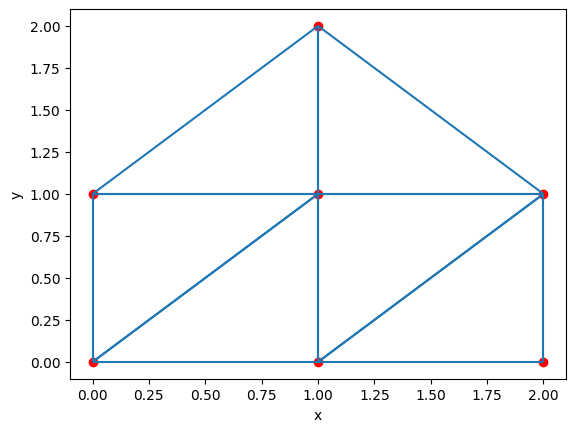

In [20]:
draw_mesh(points, triangles)

In [2]:
class HalfEdge:
    def __init__(self, origin=None, face=None, twin=None, next=None, prev=None):
        # origin: Vertex
        self.origin = origin

        # face: Face | None
        self.face = face

        # twin: HalfEdge | None
        self.twin = twin

        # next/prev: HalfEdge
        self.next = next
        self.prev = prev

In [3]:
class Vertex:
    def __init__(self, position, halfedge=None):
        # position: (float, float)
        self.position = position

        # halfedge: dowolna półkrawędź wychodząca z tego wierzchołka
        self.halfedge = halfedge

In [4]:
class Face:
    def __init__(self, halfedge=None):
        # halfedge: dowolna półkrawędź należąca do tej ściany (trójkąta)
        self.halfedge = halfedge

In [44]:
class HalfEdgeDataStructure:
    def __init__(self, points, triangles):
        self.vertices = [Vertex(pos) for pos in points]
        self.triangles = list(triangles)

        self.faces = []
        self.half_edges = []
        self.half_edges_dict = {}  # (u, v) -> HalfEdge u->v

        self._build_structure()

    def _pair_halfedge(self, u, v, e):
        # szukamy przeciwnej półkrawędzi v->u
        t = self.half_edges_dict.get((v, u))
        if t is not None:
            e.twin = t
            t.twin = e
        else:
            self.half_edges_dict[(u, v)] = e

    def _build_structure(self):
        for a, b, c in self.triangles:
            f = Face()

            e0 = HalfEdge(origin=self.vertices[a], face=f)
            e1 = HalfEdge(origin=self.vertices[b], face=f)
            e2 = HalfEdge(origin=self.vertices[c], face=f)

            e0.next, e1.next, e2.next = e1, e2, e0
            e0.prev, e1.prev, e2.prev = e2, e0, e1

            f.halfedge = e0

            if self.vertices[a].halfedge is None:
                self.vertices[a].halfedge = e0
            if self.vertices[b].halfedge is None:
                self.vertices[b].halfedge = e1
            if self.vertices[c].halfedge is None:
                self.vertices[c].halfedge = e2

            # łączenie bliźniaczych krawędzi/dodawanie krawędzi do mapy
            self._pair_halfedge(a, b, e0)
            self._pair_halfedge(b, c, e1)
            self._pair_halfedge(c, a, e2)

            self.faces.append(f)
            self.half_edges.extend([e0, e1, e2])


In [45]:
h = HalfEdgeDataStructure(points, triangles)

In [60]:
import math

def visualize_halfedge_structure(mesh,
                                 draw_mesh_edges=True,
                                 draw_vertices=True,
                                 shrink=0.15,
                                 inward_offset=0.05):
    """
    Wizualizuje Half-Edge jako krótkie odcinki przesunięte do wnętrza trójkąta,
    z kropką na końcu (kierunek półkrawędzi).
    """
    vis = Visualizer()

    def add(a, b): return (a[0] + b[0], a[1] + b[1])
    def sub(a, b): return (a[0] - b[0], a[1] - b[1])
    def mul(a, s): return (a[0] * s, a[1] * s)
    def dot(a, b): return a[0] * b[0] + a[1] * b[1]
    def length(v): return math.hypot(v[0], v[1])
    def norm(v):
        l = length(v)
        return (0.0, 0.0) if l == 0 else (v[0] / l, v[1] / l)

    # krawędzie triangulacji
    if draw_mesh_edges:
        verts_pos = [v.position for v in mesh.vertices]
        mesh_segments = []
        for a, b, c in mesh.triangles:
            mesh_segments.append((verts_pos[a], verts_pos[b]))
            mesh_segments.append((verts_pos[b], verts_pos[c]))
            mesh_segments.append((verts_pos[c], verts_pos[a]))
        vis.add_line_segment(mesh_segments)

    # wierzchołki triangulacji
    if draw_vertices:
        vis.add_point([v.position for v in mesh.vertices], color='red')

    # półkrawędzie jako odcinki + kropki na końcu
    arrow_segments = []
    tip_points = []

    for he in mesh.half_edges:
        if he.face is None or he.next is None or he.prev is None or he.origin is None:
            continue

        p0 = he.origin.position
        p1 = he.next.origin.position  # koniec półkrawędzi w half-edge

        v = sub(p1, p0)
        L = length(v)
        if L == 0:
            continue

        # środek trójkąta
        pa = he.origin.position
        pb = he.next.origin.position
        pc = he.prev.origin.position
        centroid = ((pa[0] + pb[0] + pc[0]) / 3.0, (pa[1] + pb[1] + pc[1]) / 3.0)

        # skrócenie odcinka
        base_start = add(p0, mul(v, shrink))
        base_end   = add(p0, mul(v, 1.0 - shrink))

        # przesunięcie prostopadle w stronę środka
        n = norm((-v[1], v[0]))  # normalna
        mid = ((p0[0] + p1[0]) / 2.0, (p0[1] + p1[1]) / 2.0)
        if dot(n, sub(centroid, mid)) < 0:
            n = (-n[0], -n[1])

        offset = inward_offset * L
        start = add(base_start, mul(n, offset))
        end   = add(base_end,   mul(n, offset))

        arrow_segments.append((start, end))
        tip_points.append(end)

    if arrow_segments:
        vis.add_line_segment(arrow_segments)
    if tip_points:
        vis.add_point(tip_points, color='blue')

    vis.show()


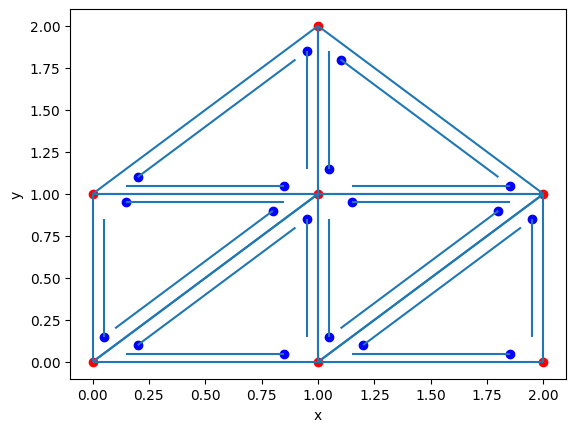

In [61]:
visualize_halfedge_structure(h)